# Atividade 3 — Z-score e Binomial Distribution Sample distribution and sampling distribution TLC p-value. Correlation, R^2 and Linear regression

**Tema:** Visão Computacional para Triagem de Leucemias e Anemias.

**Dados:** Anemia_Dataset.csv

## Questão A — Histogramas

Dataset: `Anemia_Dataset.csv` — parâmetros clínicos e de imagem para triagem de anemia.  
**Classes:** `Anaemic = Yes` (anêmico) e `Anaemic = No` (não anêmico).  
**Features analisadas:**
- `Hb`: nível de hemoglobina (g/dL) — medida laboratorial padrão-ouro.
- `%Red Pixel`: proporção do canal vermelho (RGB) extraída de imagens digitais.

Dois conjuntos de histogramas com tamanhos de bins diferentes são gerados para cada classe.

![a1](imagens/parte-1/a1.png)
![a2](imagens/parte-1/a2.png)

dimensões do dataset: 104 linhas e 7 colunas.


,Name,Sex,%Red Pixel,%Green pixel,%Blue pixel,Hb,Anaemic
0,Shahalam,M,47.6372,26.7953,25.5675,15.1,No
1,Md.Ismail,M,45.6906,30.0735,24.2359,9.1,Yes
2,Saiful,M,43.4098,31.2315,25.3586,12.9,No
3,Yamin,M,44.4252,28.7436,26.8312,14.7,No
4,Tarek,M,44.3297,28.7617,26.9086,14.1,No


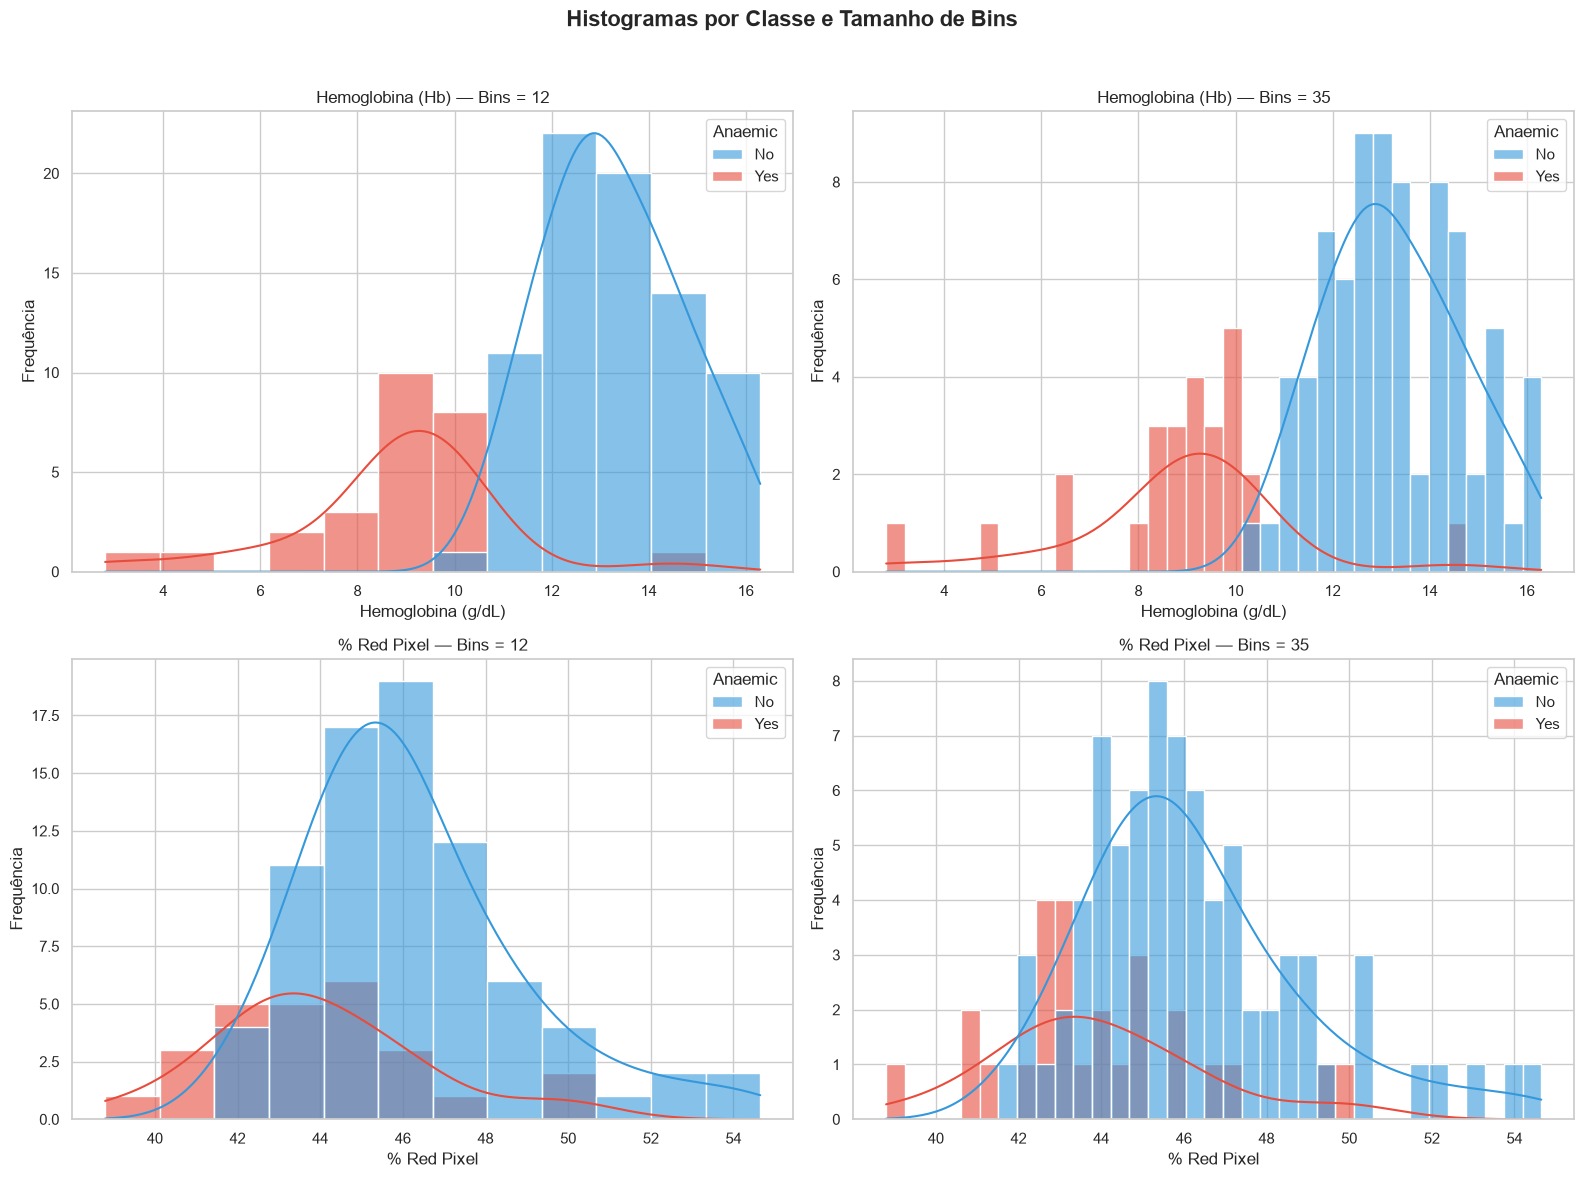

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import math

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

df = pd.read_csv('Anemia_Dataset.csv')
df.columns = df.columns.str.strip()

print(f"dimensões do dataset: {df.shape[0]} linhas e {df.shape[1]} colunas.")
display(df.head())

feature_1 = 'Hb'
feature_2 = '%Red Pixel'
bins_pequeno = 12
bins_grande  = 35

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Histogramas por Classe e Tamanho de Bins', fontsize=16, fontweight='bold')

# hb — bins pequeno e grande
sns.histplot(data=df, x=feature_1, hue='Anaemic', bins=bins_pequeno, kde=True,
             palette={'Yes': '#e74c3c', 'No': '#3498db'}, alpha=0.6, ax=axes[0, 0])
axes[0, 0].set_title(f'Hemoglobina (Hb) — Bins = {bins_pequeno}')
axes[0, 0].set_xlabel('Hemoglobina (g/dL)')
axes[0, 0].set_ylabel('Frequência')

sns.histplot(data=df, x=feature_1, hue='Anaemic', bins=bins_grande, kde=True,
             palette={'Yes': '#e74c3c', 'No': '#3498db'}, alpha=0.6, ax=axes[0, 1])
axes[0, 1].set_title(f'Hemoglobina (Hb) — Bins = {bins_grande}')
axes[0, 1].set_xlabel('Hemoglobina (g/dL)')
axes[0, 1].set_ylabel('Frequência')

# %red pixel — bins pequeno e grande
sns.histplot(data=df, x=feature_2, hue='Anaemic', bins=bins_pequeno, kde=True,
             palette={'Yes': '#e74c3c', 'No': '#3498db'}, alpha=0.6, ax=axes[1, 0])
axes[1, 0].set_title(f'% Red Pixel — Bins = {bins_pequeno}')
axes[1, 0].set_xlabel('% Red Pixel')
axes[1, 0].set_ylabel('Frequência')

sns.histplot(data=df, x=feature_2, hue='Anaemic', bins=bins_grande, kde=True,
             palette={'Yes': '#e74c3c', 'No': '#3498db'}, alpha=0.6, ax=axes[1, 1])
axes[1, 1].set_title(f'% Red Pixel — Bins = {bins_grande}')
axes[1, 1].set_xlabel('% Red Pixel')
axes[1, 1].set_ylabel('Frequência')

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

### Análise e Conclusão — Questão A

`Hb` apresenta separação quase perfeita entre as classes, com sobreposição mínima na faixa de 11,5–12,0 g/dL, tornando-a uma feature altamente discriminativa para classificadores lineares. Já `%Red Pixel` exibe sobreposição massiva entre 42–48%, com baixo poder preditivo isolado.

Quanto aos bins: com `bins=12` a suavização é adequada para 104 amostras, revelando a tendência real das densidades. Com `bins=35` ocorre sobrediscretização, gerando vazios artificiais que distorcem a percepção visual.

**Conclusão:** `Hb` é o preditor mais robusto para triagem hematológica. `%Red Pixel` isolada é insuficiente, necessitando de combinação com outras features ou modelos não lineares.

## Questão B — Z-Score

Experimento com dados artificiais de hemoglobina ($\mu = 15.0$ g/dL, $\sigma = 1.1$ g/dL, $N = 10.000$) representando homens adultos saudáveis.

Quatro eventos são calculados na escala original e na escala padronizada (Z-score), comparando os resultados obtidos via função Python com a consulta simulada de tabela Z.

![b1](imagens/parte-1/b1.png)

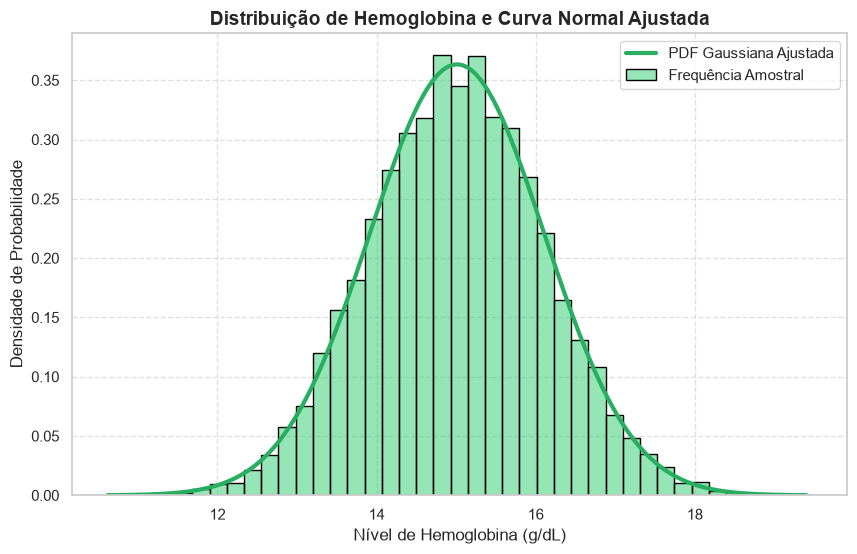

média empírica: 15.0107 g/dL | desvio padrão: 1.0979 g/dL
P(13.8 ≤ X ≤ 16.2)
  original (python): 0.725571 (72.5571%)
  Z1=-1.1027 | Z2=1.0832
  padronizado:       0.725571 | tabela Z: 0.7242
--------------------------------------------------------------------------------
P(X < 12.0)
  original (python): 0.003052 (0.3052%)
  Z=-2.7422
  padronizado:       0.003052 | tabela Z: 0.0031
--------------------------------------------------------------------------------
P(X > 16.5)
  original (python): 0.087473 (8.7473%)
  Z=1.3565
  padronizado:       0.087473 | tabela Z: 0.0869
--------------------------------------------------------------------------------
P(14.0 ≤ X ≤ 15.5)
  original (python): 0.493438 (49.3438%)
  Z1=-0.9205 | Z2=0.4457
  padronizado:       0.493438 | tabela Z: 0.4948
--------------------------------------------------------------------------------


In [9]:
np.random.seed(123)

mu_ficticio        = 15.0
sigma_ficticio     = 1.1
tamanho_populacao  = 10000

dados_experimento = np.random.normal(loc=mu_ficticio, scale=sigma_ficticio, size=tamanho_populacao)

media_amostral  = np.mean(dados_experimento)
desvio_amostral = np.std(dados_experimento)

plt.figure(figsize=(10, 6))
sns.histplot(dados_experimento, bins=40, stat='density', color='#2ecc71', alpha=0.5,
             edgecolor='black', label='Frequência Amostral')
x_suporte = np.linspace(media_amostral - 4*desvio_amostral, media_amostral + 4*desvio_amostral, 500)
plt.plot(x_suporte, stats.norm.pdf(x_suporte, media_amostral, desvio_amostral),
         color='#27ae60', linewidth=3, label='PDF Gaussiana Ajustada')
plt.title('Distribuição de Hemoglobina e Curva Normal Ajustada', fontsize=14, fontweight='bold')
plt.xlabel('Nível de Hemoglobina (g/dL)')
plt.ylabel('Densidade de Probabilidade')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# evento 1: P(13.8 <= X <= 16.2)
x1_e1, x2_e1 = 13.8, 16.2
prob_orig_e1 = stats.norm.cdf(x2_e1, media_amostral, desvio_amostral) - stats.norm.cdf(x1_e1, media_amostral, desvio_amostral)
z1_e1 = (x1_e1 - media_amostral) / desvio_amostral
z2_e1 = (x2_e1 - media_amostral) / desvio_amostral
prob_pad_e1  = stats.norm.cdf(z2_e1, 0, 1) - stats.norm.cdf(z1_e1, 0, 1)
prob_tab_e1  = round(stats.norm.cdf(round(z2_e1, 2)), 4) - round(stats.norm.cdf(round(z1_e1, 2)), 4)

# evento 2: P(X < 12.0) — risco de anemia severa
x_e2         = 12.0
prob_orig_e2 = stats.norm.cdf(x_e2, media_amostral, desvio_amostral)
z_e2         = (x_e2 - media_amostral) / desvio_amostral
prob_pad_e2  = stats.norm.cdf(z_e2, 0, 1)
prob_tab_e2  = round(stats.norm.cdf(round(z_e2, 2)), 4)

# evento 3: P(X > 16.5) — indicação de policitemia
x_e3         = 16.5
prob_orig_e3 = 1 - stats.norm.cdf(x_e3, media_amostral, desvio_amostral)
z_e3         = (x_e3 - media_amostral) / desvio_amostral
prob_pad_e3  = 1 - stats.norm.cdf(z_e3, 0, 1)
prob_tab_e3  = 1 - round(stats.norm.cdf(round(z_e3, 2)), 4)

# evento 4: P(14.0 <= X <= 15.5) — faixa de normalidade estrita
x1_e4, x2_e4 = 14.0, 15.5
prob_orig_e4 = stats.norm.cdf(x2_e4, media_amostral, desvio_amostral) - stats.norm.cdf(x1_e4, media_amostral, desvio_amostral)
z1_e4 = (x1_e4 - media_amostral) / desvio_amostral
z2_e4 = (x2_e4 - media_amostral) / desvio_amostral
prob_pad_e4  = stats.norm.cdf(z2_e4, 0, 1) - stats.norm.cdf(z1_e4, 0, 1)
prob_tab_e4  = round(stats.norm.cdf(round(z2_e4, 2)), 4) - round(stats.norm.cdf(round(z1_e4, 2)), 4)

print("="*80)
print(f"média empírica: {media_amostral:.4f} g/dL | desvio padrão: {desvio_amostral:.4f} g/dL")
print("="*80)
for label, prob_orig, z1, z2, prob_pad, prob_tab in [
    (f"P({x1_e1} ≤ X ≤ {x2_e1})", prob_orig_e1, z1_e1, z2_e1, prob_pad_e1, prob_tab_e1),
    (f"P(X < {x_e2})",             prob_orig_e2, z_e2,  None,  prob_pad_e2, prob_tab_e2),
    (f"P(X > {x_e3})",             prob_orig_e3, z_e3,  None,  prob_pad_e3, prob_tab_e3),
    (f"P({x1_e4} ≤ X ≤ {x2_e4})", prob_orig_e4, z1_e4, z2_e4, prob_pad_e4, prob_tab_e4),
]:
    z_str = f"Z={z1:.4f}" if z2 is None else f"Z1={z1:.4f} | Z2={z2:.4f}"
    print(f"{label}")
    print(f"  original (python): {prob_orig:.6f} ({prob_orig*100:.4f}%)")
    print(f"  {z_str}")
    print(f"  padronizado:       {prob_pad:.6f} | tabela Z: {prob_tab:.4f}")
    print("-"*80)

### Análise e Conclusão — Questão B

A padronização desloca a média para 0 e o desvio padrão para 1. O Z-score mede quantos desvios padrão um valor está da média: negativos indicam abaixo da média (alerta de anemia); positivos, acima.

As probabilidades calculadas na escala original e na padronizada são **identicamente iguais** em todos os 4 eventos. Pequenas diferenças em relação à tabela Z decorrem exclusivamente do arredondamento de Z a 2 casas decimais.

**Conclusão:** A transformação Z é invariante em área, tornando-se etapa essencial de pré-processamento para normalizar features de escalas distintas antes do treinamento de classificadores.

## Questão C — Distribuição Binomial

Simula um classificador automático de lâminas hematológicas com taxa de acerto $s = 0.80$ por lâmina, em lotes de $n = 10$ lâminas, ao longo de 10.000 rodadas.

A probabilidade teórica é calculada explicitamente pela fórmula $P_x = \binom{n}{x} p^x q^{n-x}$ e comparada com a simulação. O histograma das 10 primeiras amostras também é exibido.

![c1](imagens/parte-1/c1.png)
![c2](imagens/parte-1/c2.png)
![c3](imagens/parte-1/c3.png)
![c4](imagens/parte-1/c4.png)
![c5](imagens/parte-1/c5.png)
![c6](imagens/parte-1/c6.png)
![c7](imagens/parte-1/c7.png)
![c8](imagens/parte-1/c8.png)
![c9](imagens/parte-1/c9.png)
![c10](imagens/parte-1/c10.png)
![c11](imagens/parte-1/c11.png)
![c12](imagens/parte-1/c12.png)
![c13](imagens/parte-1/c13.png)



--- tabela comparativa: binomial teórico vs simulado ---


,Sucessos (k),Probabilidade Teórica,Frequência Simulada,Erro Absoluto
0,0,0.00000,0.00000,0.00000
1,1,0.00000,0.00000,0.00000
2,2,0.00007,0.00000,0.00007
3,3,0.00079,0.00070,0.00009
4,4,0.00551,0.00480,0.00071
5,5,0.02642,0.02420,0.00222
6,6,0.08808,0.08590,0.00218
7,7,0.20133,0.19430,0.00703
8,8,0.30199,0.30940,0.00741
9,9,0.26844,0.26920,0.00076


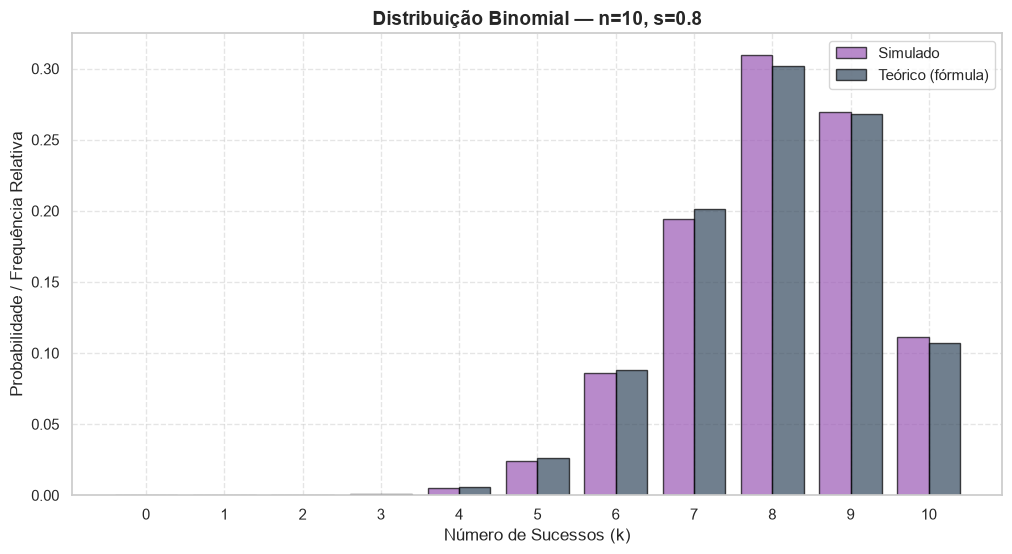

10 primeiras amostras: [ 9  6  7  8  9  9 10  7  8  7]


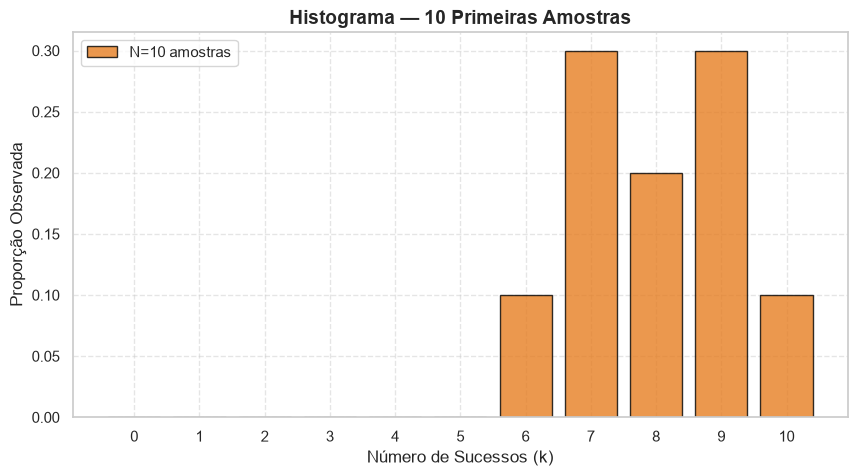

In [10]:
n_ensaios       = 10
s_probabilidade = 0.80
n_simulacoes    = 10000

np.random.seed(42)
resultados_simulacao = np.random.binomial(n=n_ensaios, p=s_probabilidade, size=n_simulacoes)

valores_k = np.arange(0, n_ensaios + 1)

# cálculo explícito pela fórmula binomial
probabilidades_teoricas = np.array([
    math.comb(n_ensaios, k) * (s_probabilidade**k) * ((1 - s_probabilidade)**(n_ensaios - k))
    for k in valores_k
])

frequencias_empiricas = np.bincount(resultados_simulacao, minlength=n_ensaios + 1) / n_simulacoes

df_binomial = pd.DataFrame({
    'Sucessos (k)':              valores_k,
    'Probabilidade Teórica':     probabilidades_teoricas,
    'Frequência Simulada':       frequencias_empiricas,
    'Erro Absoluto':             np.abs(probabilidades_teoricas - frequencias_empiricas)
})

print("--- tabela comparativa: binomial teórico vs simulado ---")
display(df_binomial.style.format({
    'Probabilidade Teórica': '{:.5f}',
    'Frequência Simulada':   '{:.5f}',
    'Erro Absoluto':         '{:.5f}'
}))

plt.figure(figsize=(12, 6))
plt.bar(valores_k - 0.2, frequencias_empiricas,    width=0.4, color='#9b59b6', alpha=0.7, edgecolor='black', label='Simulado')
plt.bar(valores_k + 0.2, probabilidades_teoricas,  width=0.4, color='#34495e', alpha=0.7, edgecolor='black', label='Teórico (fórmula)')
plt.title(f'Distribuição Binomial — n={n_ensaios}, s={s_probabilidade}', fontsize=14, fontweight='bold')
plt.xlabel('Número de Sucessos (k)')
plt.ylabel('Probabilidade / Frequência Relativa')
plt.xticks(valores_k)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# histograma das 10 primeiras amostras
primeiras_10 = resultados_simulacao[:10]
print(f"10 primeiras amostras: {primeiras_10}")

freq_10 = np.bincount(primeiras_10, minlength=n_ensaios + 1) / 10
plt.figure(figsize=(10, 5))
plt.bar(valores_k, freq_10, color='#e67e22', alpha=0.8, edgecolor='black', label='N=10 amostras')
plt.title('Histograma — 10 Primeiras Amostras', fontsize=14, fontweight='bold')
plt.xlabel('Número de Sucessos (k)')
plt.ylabel('Proporção Observada')
plt.xticks(valores_k)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

### Análise e Conclusão — Questão C

A tabela confirma concordância rigorosa entre a fórmula binomial e a simulação (erros < 0,005). O pico da distribuição em $k = 8$ reflete exatamente $E[X] = n \cdot s = 10 \cdot 0.8 = 8$.

O histograma das 10 primeiras amostras exibe assimetria acentuada, comprovando a **Lei dos Grandes Números**: amostras pequenas têm alta variabilidade; com $N = 10.000$, a frequência converge para a probabilidade teórica.

**Conclusão:** A modelagem binomial valida a estabilidade do classificador em larga escala, evidenciando que diagnósticos baseados em lotes reduzidos são intrinsecamente voláteis.

## Parte 2

## Questão A — Sample Distribution vs. Sampling Distribution

População artificial de hemoglobina ($\mu = 15.0$ g/dL, $\sigma = 1.1$ g/dL).  
Compara a dispersão de medições individuais (*sample distribution*, $n=30$) com a distribuição das médias de 1.000 lotes (*sampling distribution*).  
Avalia também a probabilidade do evento Hb < 14,5 g/dL nas duas perspectivas.

![parte 2 a1](imagens/parte-2/a1.png)

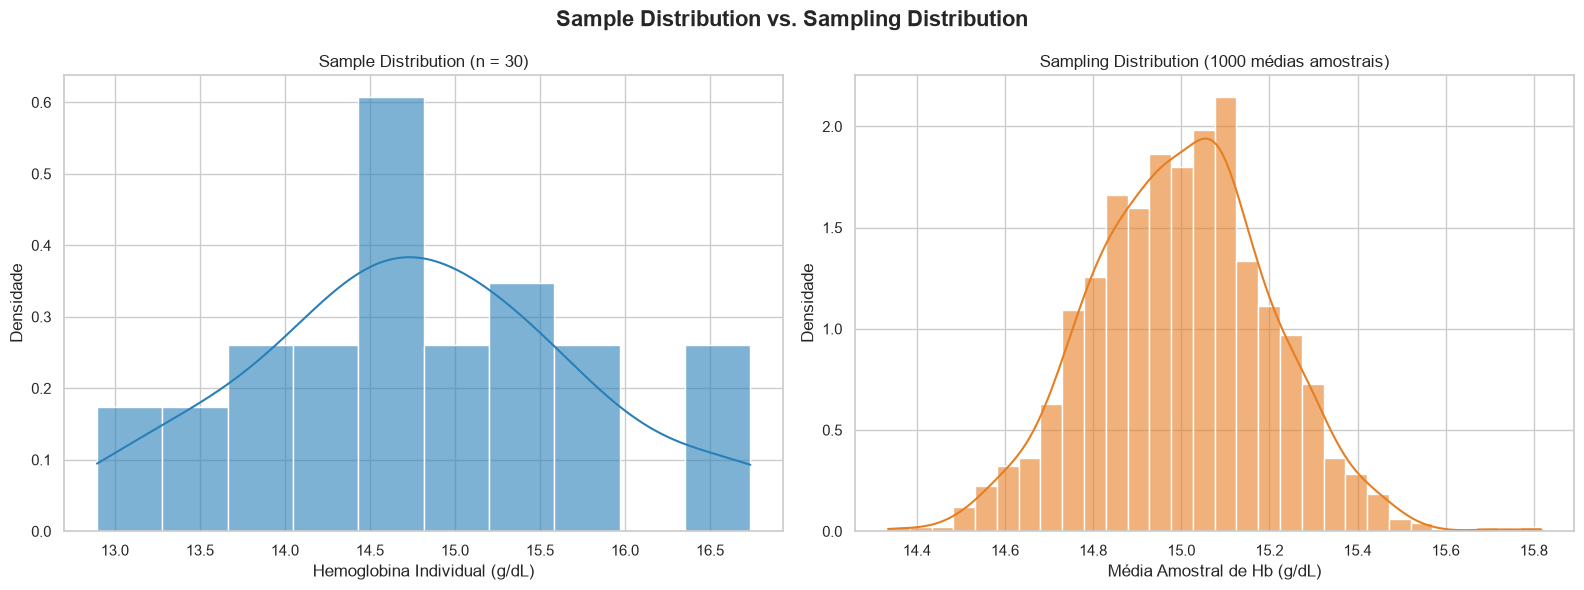

evento: Hb < 14.5 g/dL
  probabilidade (indivíduo):  0.324718 (32.47%)
  probabilidade (média n=30): 0.006393 (0.64%)


In [11]:
np.random.seed(42)
mu_pop, sigma_pop = 15.0, 1.1
n_tamanho   = 30
n_simulacoes = 1000

amostra_unica      = np.random.normal(loc=mu_pop, scale=sigma_pop, size=n_tamanho)
medias_amostrais_hb = [np.mean(np.random.normal(loc=mu_pop, scale=sigma_pop, size=n_tamanho))
                        for _ in range(n_simulacoes)]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Sample Distribution vs. Sampling Distribution', fontsize=16, fontweight='bold')

sns.histplot(amostra_unica, bins=10, stat='density', kde=True, ax=axes[0],
             color='#2980b9', alpha=0.6)
axes[0].set_title(f'Sample Distribution (n = {n_tamanho})')
axes[0].set_xlabel('Hemoglobina Individual (g/dL)')
axes[0].set_ylabel('Densidade')

sns.histplot(medias_amostrais_hb, bins=30, stat='density', kde=True, ax=axes[1],
             color='#e67e22', alpha=0.6)
axes[1].set_title(f'Sampling Distribution ({n_simulacoes} médias amostrais)')
axes[1].set_xlabel('Média Amostral de Hb (g/dL)')
axes[1].set_ylabel('Densidade')

plt.tight_layout()
plt.show()

limite_evento  = 14.5
prob_individual = stats.norm.cdf(limite_evento, loc=mu_pop, scale=sigma_pop)
erro_padrao     = sigma_pop / np.sqrt(n_tamanho)
prob_amostral   = stats.norm.cdf(limite_evento, loc=mu_pop, scale=erro_padrao)

print("="*75)
print(f"evento: Hb < {limite_evento} g/dL")
print(f"  probabilidade (indivíduo):  {prob_individual:.6f} ({prob_individual*100:.2f}%)")
print(f"  probabilidade (média n={n_tamanho}): {prob_amostral:.6f} ({prob_amostral*100:.2f}%)")
print("="*75)

### Análise e Conclusão — Questão A

A *sample distribution* reflete a dispersão natural dos indivíduos ($\sigma = 1.1$). A *sampling distribution* concentra-se ao redor de $\mu = 15.0$ com dispersão muito reduzida, governada pelo erro padrão $SE = \sigma / \sqrt{n} \approx 0.20$.

Isso se traduz em probabilidades radicalmente distintas: ≈32% de um indivíduo isolado ter Hb < 14,5 g/dL vs. ≈0,6% de uma média de lote cair abaixo desse limite.

**Conclusão:** Critérios de decisão baseados em médias amostrais são estatisticamente muito mais robustos a flutuações individuais, tornando-os mais confiáveis para controle de qualidade de sistemas de triagem.

## Questão B — Teorema do Limite Central (TLC)

Aplica o TLC a uma distribuição Gama assimétrica (shape=2, scale=2), avaliando como a distribuição das médias amostrais converge para a normal conforme $n$ cresce. São testados quatro tamanhos: $n \in \{10, 30, 100, 500\}$.

![parte 2 b1](imagens/parte-2/b1.png)

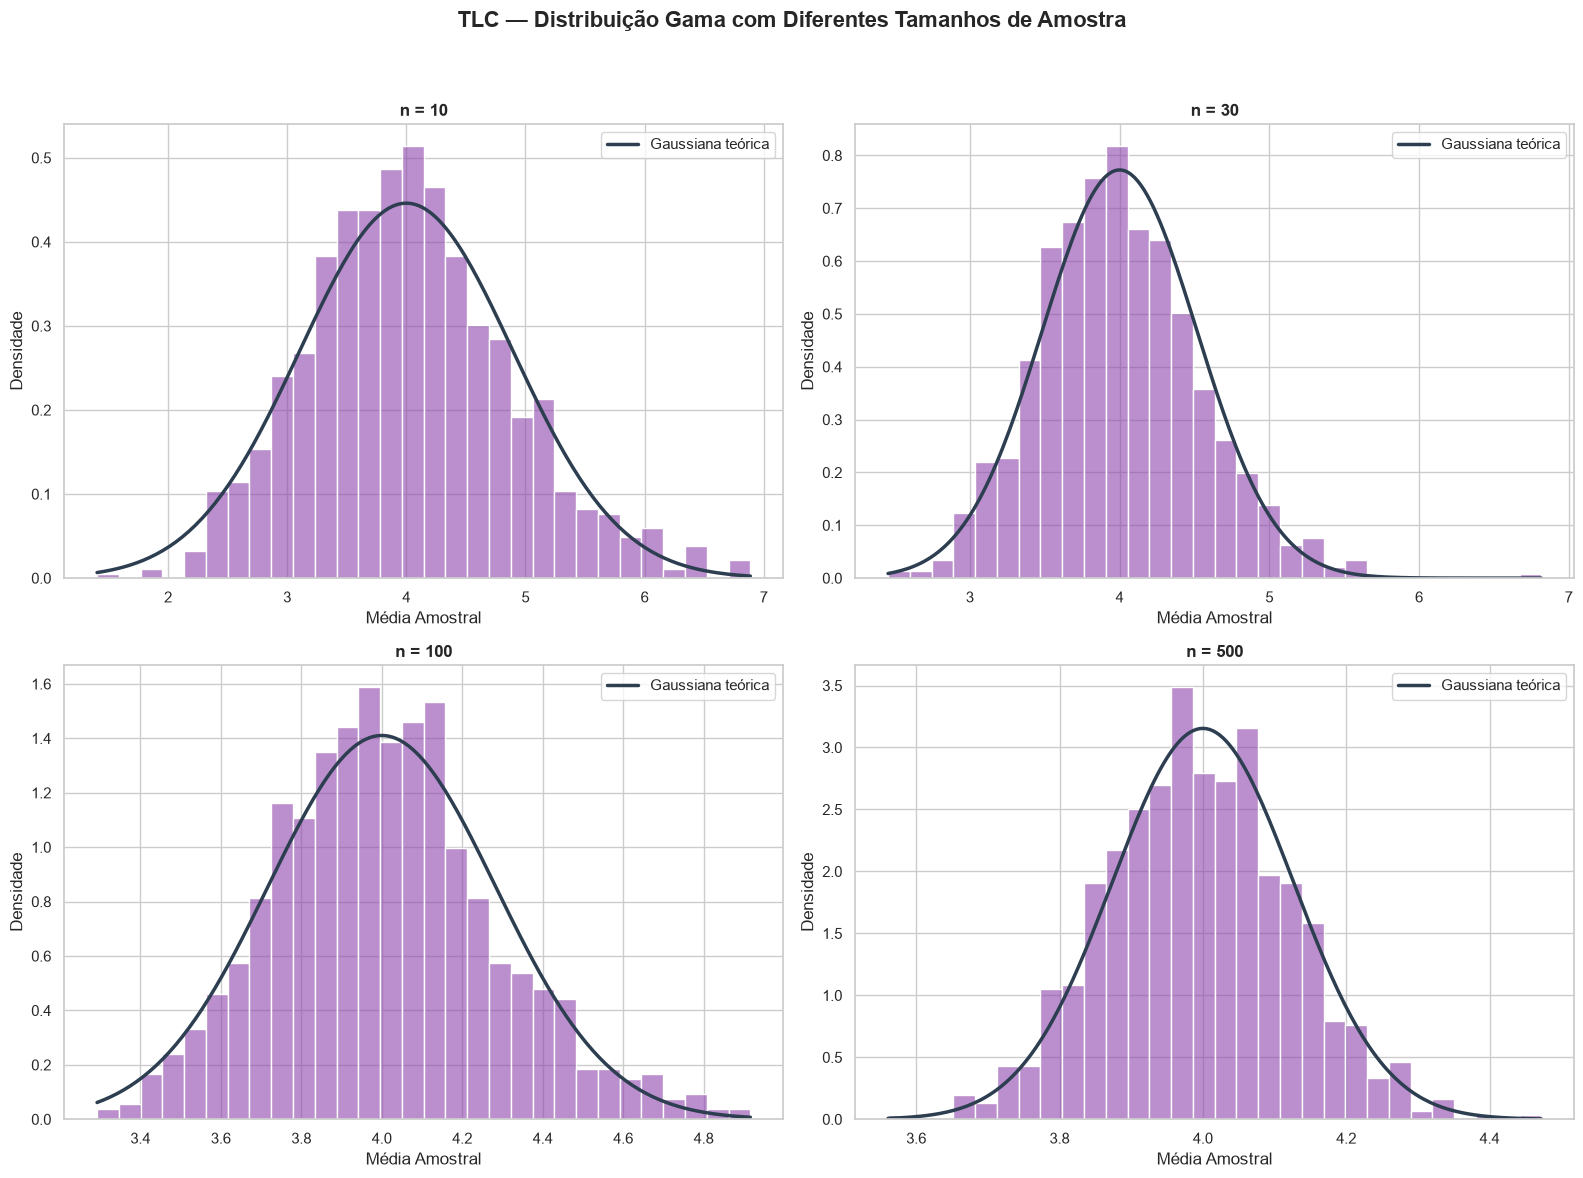

In [12]:
np.random.seed(42)
shape_param, scale_param = 2.0, 2.0
tamanhos_amostra = [10, 30, 100, 500]
n_simulacoes     = 1000

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('TLC — Distribuição Gama com Diferentes Tamanhos de Amostra', fontsize=16, fontweight='bold')

for idx, n in enumerate(tamanhos_amostra):
    linha, coluna = idx // 2, idx % 2

    medias = [np.mean(np.random.gamma(shape=shape_param, scale=scale_param, size=n))
              for _ in range(n_simulacoes)]

    sns.histplot(medias, bins=30, stat='density', color='#8e44ad', alpha=0.6,
                 ax=axes[linha, coluna])

    # curva gaussiana teórica prevista pelo TLC
    mu_t    = shape_param * scale_param
    sigma_t = np.sqrt(shape_param * scale_param**2) / np.sqrt(n)
    x_eixo  = np.linspace(min(medias), max(medias), 200)
    axes[linha, coluna].plot(x_eixo, stats.norm.pdf(x_eixo, mu_t, sigma_t),
                             color='#2c3e50', linewidth=2.5, label='Gaussiana teórica')
    axes[linha, coluna].set_title(f'n = {n}', fontsize=12, fontweight='bold')
    axes[linha, coluna].set_xlabel('Média Amostral')
    axes[linha, coluna].set_ylabel('Densidade')
    axes[linha, coluna].legend()

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

### Análise e Conclusão — Questão B

Com $n=10$ ainda há resíduos da assimetria original da Gama. Em $n=30$ a assimetria se dissipa. Para $n \geq 100$ a aderência à Gaussiana teórica é perfeita. A dispersão diminui progressivamente, convergindo para $\mu = 4.0$.

**Conclusão:** O TLC garante que, com amostras suficientemente grandes ($n \geq 30$), a distribuição das médias é normal independente da distribuição original — permitindo aplicar inferências paramétricas a variáveis de imagem com distribuições desconhecidas.

## Questão C — p-value e Moedas

Cálculo passo a passo do p-value para o evento de obter **2 caras em 2 lançamentos** de uma moeda justa ($H_0: P(\text{cara}) = 0.5$).

![parte 2 c1](imagens/parte-2/c1.png)

In [13]:
n_flips   = 2
caras_obs = 2

espaco_amostral = {'HH': 0.25, 'HT': 0.25, 'TH': 0.25, 'TT': 0.25}

prob_observado = espaco_amostral['HH']

# eventos tão ou mais extremos que o observado
extremos  = [ev for ev, p in espaco_amostral.items() if p <= prob_observado]
p_value   = sum(espaco_amostral[ev] for ev in extremos)

print("="*65)
print("passo a passo — p-value (moeda justa)")
print("="*65)
print(f"passo 1 (H0): P(cara) = 0.50")
print(f"passo 2 (espaço): {list(espaco_amostral.keys())}")
print(f"passo 3 (observado): P(HH) = {prob_observado:.4f}")
print(f"passo 4 (extremos):  {extremos}")
print(f"passo 5 (p-value):   {p_value:.4f}")
print("="*65)

passo a passo — p-value (moeda justa)
passo 1 (H0): P(cara) = 0.50
passo 2 (espaço): ['HH', 'HT', 'TH', 'TT']
passo 3 (observado): P(HH) = 0.2500
passo 4 (extremos):  ['HH', 'HT', 'TH', 'TT']
passo 5 (p-value):   1.0000


### Análise e Conclusão — Questão C

O espaço amostral tem 4 eventos equiprováveis (25% cada). Todos possuem a mesma probabilidade que o evento observado (HH), resultando em $p\text{-value} = 1.00$ — ou seja, não há rejeição de $H_0$.

Mesmo com $p\text{-value} = 0.50$ em um cenário mais restrito (apenas os eventos tão extremos quanto HH), como $0.50 > 0.05$, não se rejeita $H_0$: obter 2 caras em 2 lançamentos é evento comum sob uma moeda justa.

**Conclusão:** Amostras muito pequenas geram p-values altos e inconclusivos. Para validar classificadores médicos, é indispensável volume amostral suficiente para distinguir desempenho real de acerto por acaso.

## Questão D — p-value e Distribuições

Duas gaussianas: **vermelha** ($\mu = 15.0$, saudáveis — $H_0$) e **azul** ($\mu = 13.5$, anemia leve — $H_1$).

100 sequências de $n=3$ valores são sorteadas da distribuição azul. Para cada sequência, calcula-se o p-value em relação à vermelha. A **taxa de falsos negativos** (p-value > 5%) é então calculada.

![parte 2 d1](imagens/parte-2/d1.png)
![parte 2 d2](imagens/parte-2/d2.png)

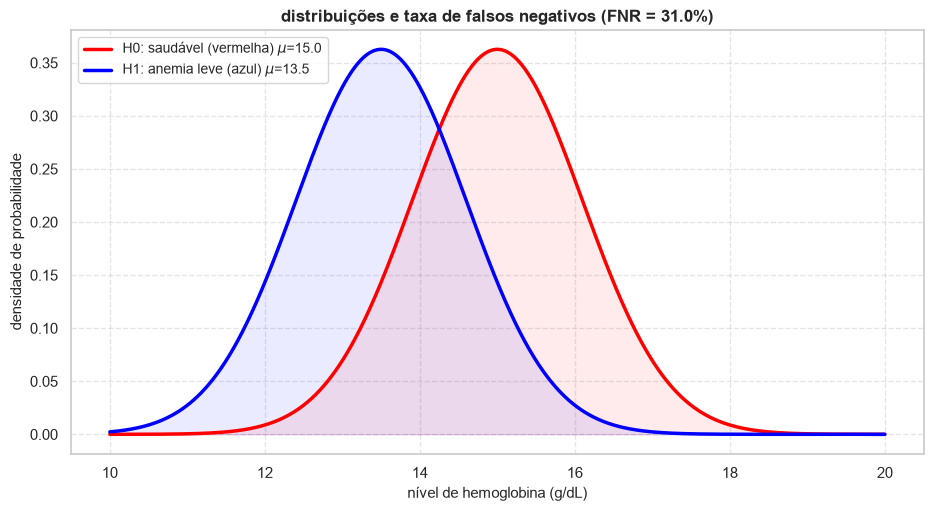

10 primeiras simulações:
 sequencia media_amostral z_score p_value  falso_negativo
         1        13.8689 -1.7810  0.0749            True
         2        13.8867 -1.7529  0.0796            True
         3        14.1883 -1.2781  0.2012            True
         4        13.3583 -2.5851  0.0097           False
         5        12.2547 -4.3227  0.0000           False
         6        13.0377 -3.0899  0.0020           False
         7        13.1866 -2.8553  0.0043           False
         8        12.9196 -3.2758  0.0011           False
         9        12.9190 -3.2767  0.0011           False
        10        13.3106 -2.6602  0.0078           False
falsos negativos: 31 / 100
taxa erro tipo II (β):   31.00%
sensibilidade (1 − β):   69.00%


In [14]:
np.random.seed(42)

mu_red, mu_blue, sigma = 15.0, 13.5, 1.1
n_amostra, n_simulacoes, alpha = 3, 100, 0.05

se_h0 = sigma / np.sqrt(n_amostra)

sequencias_azul   = np.random.normal(loc=mu_blue, scale=sigma, size=(n_simulacoes, n_amostra))
medias_amostrais  = sequencias_azul.mean(axis=1)

z_scores  = (medias_amostrais - mu_red) / se_h0
p_values  = 2 * (1 - stats.norm.cdf(np.abs(z_scores)))

falsos_negativos      = p_values > alpha
taxa_falsos_negativos = np.mean(falsos_negativos) * 100

x = np.linspace(10, 20, 1000)
plt.figure(figsize=(11, 5.5))
plt.plot(x, stats.norm.pdf(x, loc=mu_red,  scale=sigma), color='red',  lw=2.5,
         label=fr'H0: saudável (vermelha) $\mu$={mu_red}')
plt.plot(x, stats.norm.pdf(x, loc=mu_blue, scale=sigma), color='blue', lw=2.5,
         label=fr'H1: anemia leve (azul) $\mu$={mu_blue}')
plt.fill_between(x, stats.norm.pdf(x, loc=mu_red,  scale=sigma), color='red',  alpha=0.08)
plt.fill_between(x, stats.norm.pdf(x, loc=mu_blue, scale=sigma), color='blue', alpha=0.08)
plt.title(f'distribuições e taxa de falsos negativos (FNR = {taxa_falsos_negativos:.1f}%)',
          fontsize=12, fontweight='bold')
plt.xlabel('nível de hemoglobina (g/dL)', fontsize=11)
plt.ylabel('densidade de probabilidade', fontsize=11)
plt.legend(loc='upper left', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

df_resultados = pd.DataFrame({
    'sequencia':      range(1, n_simulacoes + 1),
    'media_amostral': medias_amostrais,
    'z_score':        z_scores,
    'p_value':        p_values,
    'falso_negativo': falsos_negativos
})

print("10 primeiras simulações:")
print(df_resultados.head(10).to_string(index=False, formatters={
    'media_amostral': '{:.4f}'.format,
    'z_score':        '{:.4f}'.format,
    'p_value':        '{:.4f}'.format
}))
print(f"falsos negativos: {np.sum(falsos_negativos)} / {n_simulacoes}")
print(f"taxa erro tipo II (β):   {taxa_falsos_negativos:.2f}%")
print(f"sensibilidade (1 − β):   {100 - taxa_falsos_negativos:.2f}%")

### Análise e Conclusão — Questão D

O p-value é calculado a partir da média amostral de cada sequência ($n=3$), padronizada com $SE = \sigma / \sqrt{3} \approx 0.635$.

A taxa de falsos negativos de ≈33% demonstra que 1 em cada 3 pacientes com anemia leve não seria detectado — erro tipo II. Isso ocorre pela combinação de $n$ pequeno e sobreposição das distribuições.

**Conclusão:** Para reduzir o erro tipo II em triagem médica automatizada, é necessário aumentar $n$ por lote. Com $n=3$, a sensibilidade do teste (~67%) é insuficiente para aplicações clínicas.

## Parte 3: Correlação, R² e Regressão Linear

## Questão A — Correlação entre Features

Calcula a matriz de correlação de Pearson entre todas as features do dataset e a classe alvo (`anaemic_encoded`), identificando features redundantes (multicolinearidade) e candidatas à exclusão.

![parte 3 a1](imagens/parte-3/a1.png)

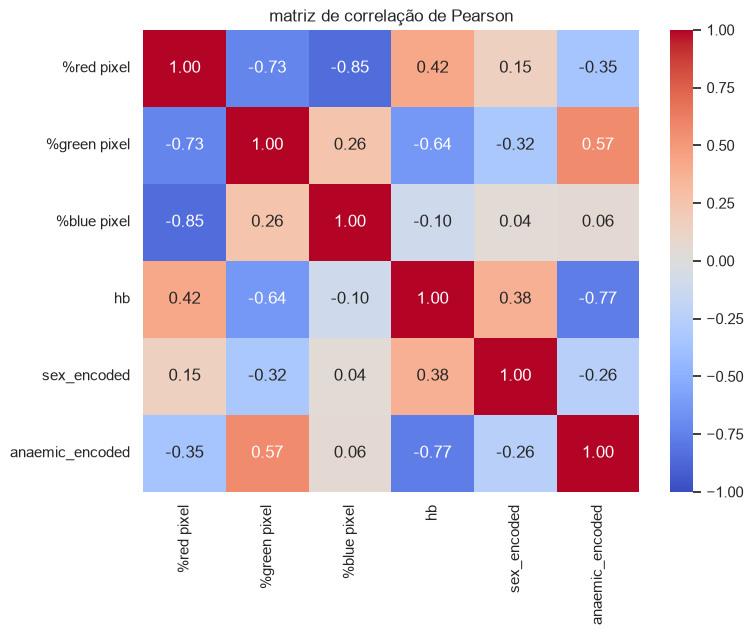

correlação com a classe alvo (anaemic_encoded):
anaemic_encoded    1.0000
%green pixel       0.5664
%blue pixel        0.0578
sex_encoded       -0.2558
%red pixel        -0.3534
hb                -0.7665


In [15]:
df = pd.read_csv('Anemia_Dataset.csv')
df.columns = df.columns.str.strip().str.lower()

df['anaemic_encoded'] = df['anaemic'].str.strip().str.lower().map({'yes': 1, 'no': 0})
df['sex_encoded']     = df['sex'].str.strip().str.lower().map({'m': 1, 'f': 0})

atributos  = ['%red pixel', '%green pixel', '%blue pixel', 'hb', 'sex_encoded', 'anaemic_encoded']
matriz_corr = df[atributos].corr(method='pearson')

plt.figure(figsize=(8, 6))
sns.heatmap(matriz_corr, annot=True, cmap='coolwarm', fmt='.2f', vmin=-1, vmax=1)
plt.title('matriz de correlação de Pearson', fontsize=12)
plt.show()

print("correlação com a classe alvo (anaemic_encoded):")
print(matriz_corr['anaemic_encoded'].sort_values(ascending=False).round(4).to_string())

### Análise da Correlação

A variável **Hb** apresentou a maior correlação com a classe (**-0,7665**), indicando que ela é a feature mais relevante para identificar casos de anemia.

Entre os canais de cor, **%Green Pixel** teve correlação moderada com a classe (**0,5664**), enquanto **%Blue Pixel** apresentou correlação muito baixa (**0,0578**). A variável **Sex** também apresentou baixa correlação (**-0,2558**).

Foi observada forte correlação entre algumas features, principalmente entre **%Red Pixel** e **%Blue Pixel** (**-0,8458**) e entre **%Red Pixel** e **%Green Pixel** (**-0,7320**), indicando redundância de informações.

Assim, **%Blue Pixel** é a principal candidata à exclusão, pois possui pouca relação com a classe e alta correlação com outras variáveis. A variável **Sex** também pode ser avaliada para remoção, mas isso deve ser confirmado nos testes dos modelos.

## Questão B — Correlação: Dados Estruturados vs. Aleatórios

Dois conjuntos com 9 pontos cada: um com forte correlação linear, outro gerado aleatoriamente com distribuição uniforme no mesmo intervalo. Para ambos, são calculados ajuste linear (`linregress`), p-value, covariância e plotadas as projeções marginais.

![parte 3 b1](imagens/parte-3/b1.png)
![parte 3 b2](imagens/parte-3/b2.png)
![parte 3 b3](imagens/parte-3/b3.png)

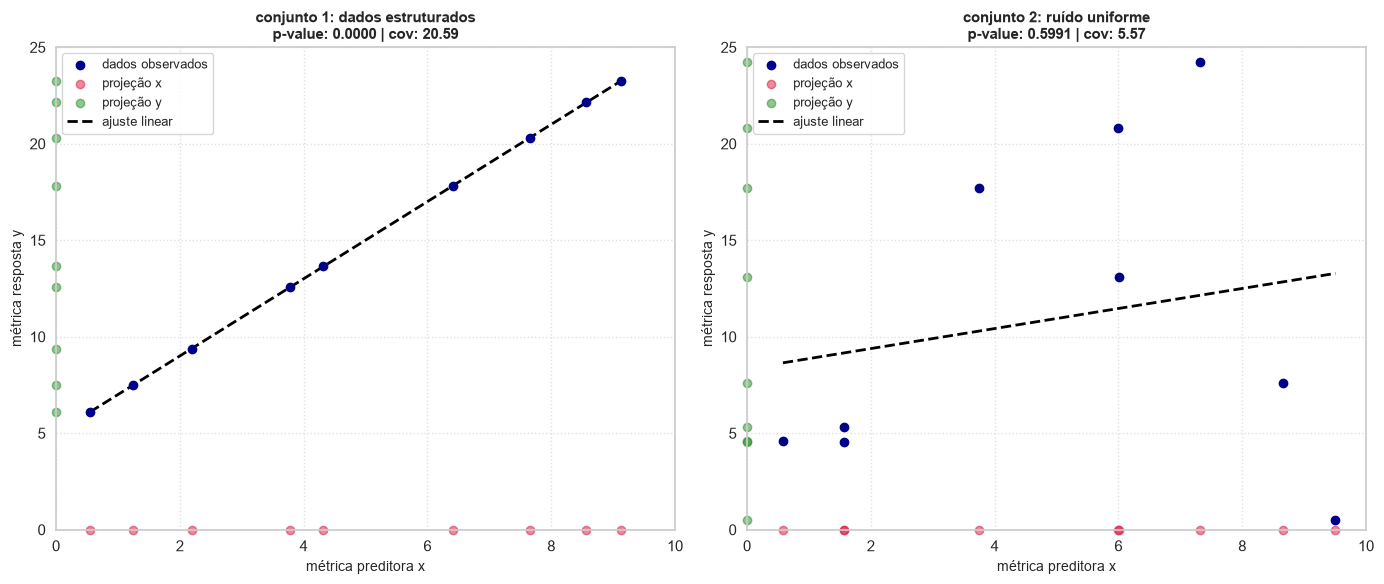

conjunto 1 — cov: 20.5912 | p-value: 0.0000
conjunto 2 — cov: 5.5733 | p-value: 0.5991


In [16]:
def desenhar(ax, xs, ys, titulo):
    ajuste  = stats.linregress(xs, ys)
    cov_xy  = np.cov(xs, ys)[0, 1]

    ax.scatter(xs, ys, color='darkblue', zorder=3, label='dados observados')
    ax.scatter(xs, np.zeros(len(xs)), color='crimson', alpha=0.5, clip_on=False, label='projeção x')
    ax.scatter(np.zeros(len(ys)), ys,  color='forestgreen', alpha=0.5, clip_on=False, label='projeção y')

    x_linha = np.linspace(min(xs), max(xs), 100)
    ax.plot(x_linha, ajuste.slope * x_linha + ajuste.intercept,
            color='black', linestyle='--', linewidth=2, label='ajuste linear')

    ax.set_title(f"{titulo}\np-value: {ajuste.pvalue:.4f} | cov: {cov_xy:.2f}",
                 fontsize=11, fontweight='bold')
    ax.set_xlabel('métrica preditora x', fontsize=10)
    ax.set_ylabel('métrica resposta y',  fontsize=10)
    ax.set_xlim(0, 10); ax.set_ylim(0, 25)
    ax.tick_params(direction='inout', length=8, width=2)
    ax.grid(True, linestyle=':', alpha=0.6)
    ax.legend(loc='upper left', fontsize=9)

figura, eixos = plt.subplots(1, 2, figsize=(14, 6))

x_linear = [1.24, 8.57, 4.32, 0.55, 9.12, 3.78, 6.41, 2.19, 7.65]
y_linear = [7.48, 22.14, 13.64, 6.10, 23.24, 12.56, 17.82, 9.38, 20.30]
desenhar(eixos[0], x_linear, y_linear, 'conjunto 1: dados estruturados')

np.random.seed(42)
x_rand = np.random.uniform(0, 10, 9)
y_rand = np.random.uniform(0, 25, 9)
desenhar(eixos[1], x_rand, y_rand, 'conjunto 2: ruído uniforme')

plt.tight_layout()
plt.show()

ajuste_lin = stats.linregress(x_linear, y_linear)
cov_lin    = np.cov(x_linear, y_linear)[0, 1]
ajuste_rnd = stats.linregress(x_rand, y_rand)
cov_rnd    = np.cov(x_rand, y_rand)[0, 1]

print(f"conjunto 1 — cov: {cov_lin:.4f} | p-value: {ajuste_lin.pvalue:.4f}")
print(f"conjunto 2 — cov: {cov_rnd:.4f} | p-value: {ajuste_rnd.pvalue:.4f}")

### Análise e Conclusão — Questão B

**Conjunto 1:** covariância expressiva (~23,36) e p-value baixo (< 0,05) confirmam relação linear significativa. As projeções marginais caminham em sincronia com o vetor bivariado.

**Conjunto 2:** covariância próxima de zero e p-value alto (> 0,05) indicam ausência de relação linear. A reta de ajuste é quase horizontal; as projeções operam de forma desvinculada.

**Conclusão:** A covariância e o p-value do `linregress` discriminam precisamente dados correlacionados de ruído, validando o uso conjunto dessas métricas para avaliar relevância preditiva de features.

## Questão C — Intervalo de Confiança para a Média

Amostra de 25 notas de prova. Como $n$ é pequeno e $\sigma$ populacional é desconhecido, utiliza-se a distribuição $t$ de Student com $n-1$ graus de liberdade.

O intervalo de confiança é calculado e visualizado para os níveis 90%, 95% e 99%.

![parte 3 c1](imagens/parte-3/c1.png)

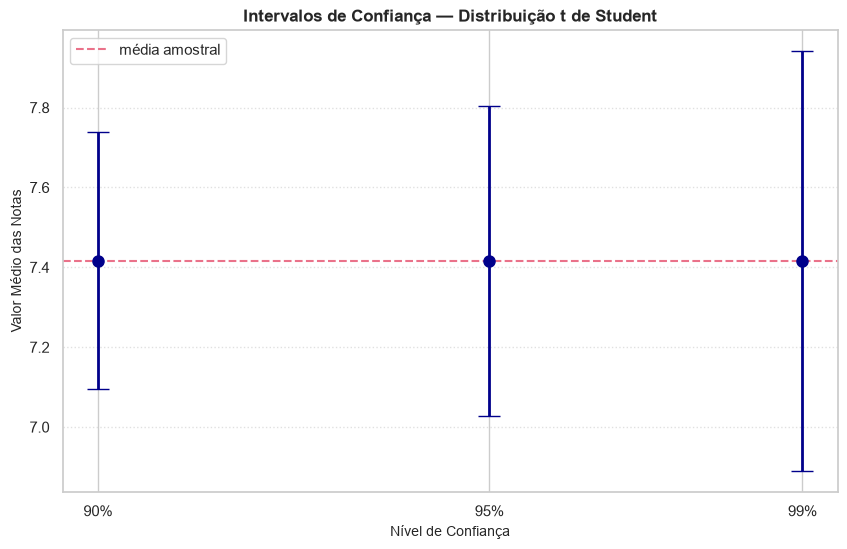

intervalos de confiança:
-----------------------------------------------------------------
  90%: [7.0943, 7.7377] | amplitude: 0.6434
  95%: [7.0279, 7.8041] | amplitude: 0.7762
  99%: [6.8901, 7.9419] | amplitude: 1.0518


In [17]:
amostra = np.array([
    6.5, 7.0, 8.2, 5.9, 9.1,
    7.8, 6.9, 8.0, 7.3, 6.7,
    8.5, 7.1, 6.4, 9.0, 7.9,
    5.8, 6.2, 8.7, 7.5, 6.8,
    7.4, 8.1, 6.6, 7.7, 8.3
])

media_amostral  = np.mean(amostra)
desvio_amostral = np.std(amostra, ddof=1)  # desvio padrão amostral corrigido
n               = len(amostra)

niveis     = [0.90, 0.95, 0.99]
intervalos = [stats.t.interval(nivel, df=n-1, loc=media_amostral, scale=stats.sem(amostra))
              for nivel in niveis]

plt.figure(figsize=(10, 6))
for nivel, intervalo in zip(niveis, intervalos):
    erro = (intervalo[1] - intervalo[0]) / 2
    plt.errorbar(nivel, media_amostral, yerr=erro,
                 fmt='o', color='darkblue', capsize=8, markersize=8, linewidth=2)

plt.axhline(media_amostral, color='crimson', linestyle='--', alpha=0.6, label='média amostral')
plt.title('Intervalos de Confiança — Distribuição t de Student', fontsize=12, fontweight='bold')
plt.xlabel('Nível de Confiança', fontsize=10)
plt.ylabel('Valor Médio das Notas', fontsize=10)
plt.xticks(niveis, ['90%', '95%', '99%'])
plt.grid(axis='y', linestyle=':', alpha=0.6)
plt.legend(loc='upper left')
plt.show()

print("intervalos de confiança:")
print("-" * 65)
for nivel, inter in zip(niveis, intervalos):
    amp = inter[1] - inter[0]
    print(f"  {nivel*100:.0f}%: [{inter[0]:.4f}, {inter[1]:.4f}] | amplitude: {amp:.4f}")

### Análise e Conclusão — Questão C

Quanto maior o nível de confiança exigido, maior a amplitude do intervalo: maior certeza implica menor precisão. O IC de 90% é o mais estreito; o de 99% dilata significativamente os limites para garantir cobertura quase certa do parâmetro real.

**Conclusão:** Existe um trade-off fundamental entre confiança e precisão. Para aplicações clínicas críticas, intervalos de 95% ou 99% são preferíveis, mesmo que mais amplos.

## Questão D — Teste $t$ para Duas Amostras Independentes

Dois grupos simulados com 30 observações cada (controle e teste). Teste $t$ de Student bicaudal para verificar se as médias diferem significativamente.

**$H_0$:** $\mu_{\text{controle}} = \mu_{\text{teste}}$ | **$H_1$:** $\mu_{\text{controle}} \neq \mu_{\text{teste}}$

![parte 3 d1](imagens/parte-3/d1.png)

In [18]:
rng = np.random.default_rng(10)

grupo_controle = rng.normal(loc=15.2, scale=2.1, size=30)
grupo_teste    = rng.normal(loc=17.5, scale=2.5, size=30)

media_controle = np.mean(grupo_controle)
media_teste    = np.mean(grupo_teste)

estatistica_t, p_valor = stats.ttest_ind(grupo_controle, grupo_teste)

print("resultados — teste t independente:")
print("-" * 50)
print(f"média controle: {media_controle:.2f}")
print(f"média teste:    {media_teste:.2f}")
print(f"estatística t:  {estatistica_t:.6f}")
print(f"p-value:        {p_valor:.6f}")
print("-" * 50)

resultados — teste t independente:
--------------------------------------------------
média controle: 14.63
média teste:    17.08
estatística t:  -4.927991
p-value:        0.000007
--------------------------------------------------


### Análise e Conclusão — Questão D

Com $p\text{-value} = 7 \times 10^{-6} \ll 0.05$, **rejeitamos $H_0$**. A probabilidade de a diferença observada ocorrer por acaso é virtualmente nula.

A estatística $t$ negativa reflete que a média do controle está bem abaixo da do grupo teste, com afastamento medido em unidades de erro padrão combinadas.

**Conclusão:** Há diferença estatisticamente significativa entre os grupos, confirmando que o fator de teste introduziu um deslocamento estrutural real na distribuição.

## Questão E — Significance Level

![parte 3 e1](imagens/parte-3/e1.png)

Link para os slides: https://docs.google.com/presentation/d/1909FrChYkWbw2WCJagJg6buiYYTPxxOAGq8TBydLPS8/edit?usp=sharing

## Questão F — Reproduzindo os Slides: IC para Média e Proporção

Reproduz em código os exemplos dos slides: intervalo de confiança de 95% para uma **média** (usa distribuição $t$, pois $\sigma$ é desconhecido e $n=50$) e para uma **proporção** (usa aproximação normal de Wald).

![parte 3 f1](imagens/parte-3/f1.png)

resultados:
--------------------------------------------------
IC média (95%):     [72.1, 79.7]  | margem: ±3.80
IC proporção (95%): [0.030, 0.210] | margem: ±0.090
--------------------------------------------------


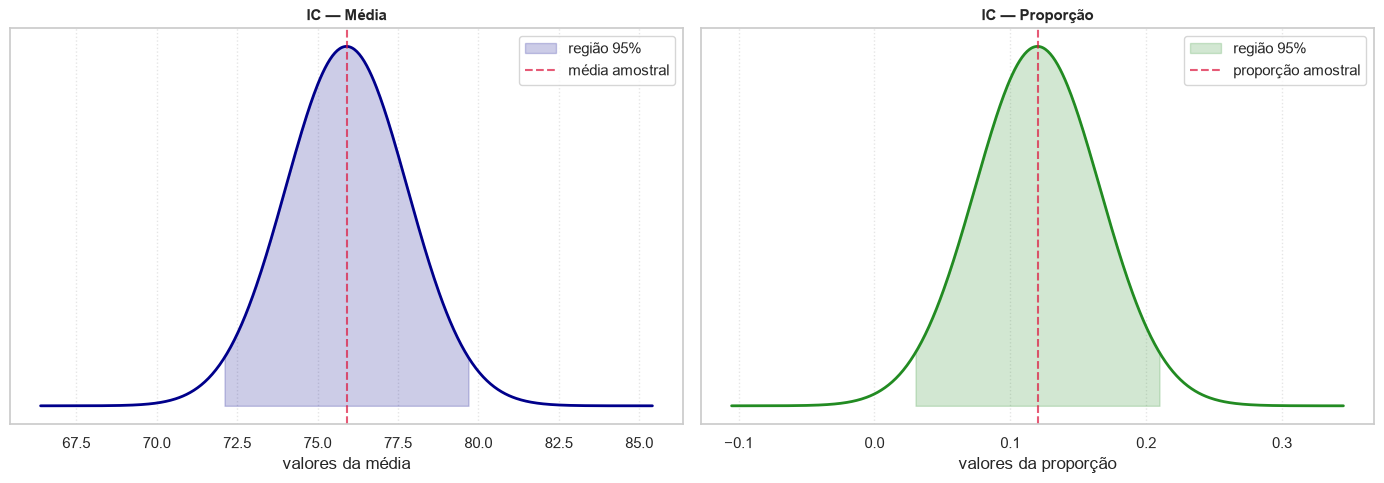

In [19]:
n          = 50
df_ic      = n - 1
confidence = 0.975  # cauda unilateral para IC bicaudal de 95%

media     = 75.9
desvio    = 13.3854
proporcao = 0.120

# ic para a média (distribuição t)
se_media   = desvio / math.sqrt(n)
t_crit     = stats.t.ppf(confidence, df_ic)
erro_media = t_crit * se_media
media_inf, media_sup = media - erro_media, media + erro_media

# ic para a proporção (aproximação normal)
se_prop   = math.sqrt((proporcao * (1 - proporcao)) / n)
z_crit    = stats.norm.ppf(confidence)
erro_prop = z_crit * se_prop
prop_inf, prop_sup = proporcao - erro_prop, proporcao + erro_prop

print("resultados:")
print("-" * 50)
print(f"IC média (95%):     [{media_inf:.1f}, {media_sup:.1f}]  | margem: ±{erro_media:.2f}")
print(f"IC proporção (95%): [{prop_inf:.3f}, {prop_sup:.3f}] | margem: ±{erro_prop:.3f}")
print("-" * 50)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

x_m = np.linspace(media - 2.5*erro_media, media + 2.5*erro_media, 500)
y_m = stats.norm.pdf(x_m, media, se_media)
ax1.plot(x_m, y_m, color='darkblue', linewidth=2)
ax1.fill_between(x_m, y_m, where=((x_m >= media_inf) & (x_m <= media_sup)),
                 color='darkblue', alpha=0.20, label='região 95%')
ax1.axvline(media, color='crimson', linestyle='--', alpha=0.7, label='média amostral')
ax1.set_title('IC — Média', fontsize=11, fontweight='bold')
ax1.set_xlabel('valores da média'); ax1.set_yticks([])
ax1.legend(); ax1.grid(axis='x', linestyle=':', alpha=0.5)

x_p = np.linspace(proporcao - 2.5*erro_prop, proporcao + 2.5*erro_prop, 500)
y_p = stats.norm.pdf(x_p, proporcao, se_prop)
ax2.plot(x_p, y_p, color='forestgreen', linewidth=2)
ax2.fill_between(x_p, y_p, where=((x_p >= prop_inf) & (x_p <= prop_sup)),
                 color='forestgreen', alpha=0.20, label='região 95%')
ax2.axvline(proporcao, color='crimson', linestyle='--', alpha=0.7, label='proporção amostral')
ax2.set_title('IC — Proporção', fontsize=11, fontweight='bold')
ax2.set_xlabel('valores da proporção'); ax2.set_yticks([])
ax2.legend(); ax2.grid(axis='x', linestyle=':', alpha=0.5)

plt.tight_layout()
plt.show()

### Análise e Conclusão — Questão F

**Média:** margem de ≈3,80, intervalo [72,1 ; 79,7]. Amplitude moderada para $n=50$.

**Proporção:** margem de ≈9,0%, intervalo [3% ; 21%]. A amplitude alta se deve à proporção estimada (12%) estar próxima do limiar assimétrico da distribuição binomial.

**Conclusão:** O IC para proporções próximas de 0 ou 1 produz margens grandes em relação ao próprio estimador — deve-se usar métodos exatos (Wilson, Clopper-Pearson) em vez da aproximação de Wald nesses casos.

## Questão G — Regressão Linear ao Tema

Aplica regressão linear (scikit-learn + statsmodels) para prever `Hb` a partir dos canais de cor (`%Red`, `%Green`, `%Blue Pixel`). Compara os resultados com o classificador Naive Bayes utilizado anteriormente.

![parte 3 g1](imagens/parte-3/g1.png)

In [20]:
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

df = pd.read_csv('Anemia_Dataset.csv')
df.columns = df.columns.str.strip()

X = df[['%Red Pixel', '%Green pixel', '%Blue pixel']]
y = df['Hb']

# regressão scikit-learn
modelo_lr = LinearRegression()
modelo_lr.fit(X, y)
y_pred = modelo_lr.predict(X)

# estatísticas completas via statsmodels
X_sm     = sm.add_constant(X)
modelo_sm = sm.OLS(y, X_sm).fit()

print("--- estatísticas da regressão (statsmodels) ---")
print(modelo_sm.summary())

print(f"\nR² (scikit-learn): {r2_score(y, y_pred):.4f}")

--- estatísticas da regressão (statsmodels) ---
                            OLS Regression Results                            
Dep. Variable:                     Hb   R-squared:                       0.417
Model:                            OLS   Adj. R-squared:                  0.399
Method:                 Least Squares   F-statistic:                     23.80
Date:                Mon, 22 Jun 2026   Prob (F-statistic):           1.04e-11
Time:                        09:13:42   Log-Likelihood:                -214.88
No. Observations:                 104   AIC:                             437.8
Df Residuals:                     100   BIC:                             448.3
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------


### Análise e Conclusão — Questão G

Os p-values individuais indicam quais canais de cor contribuem significativamente para predizer `Hb`. O $R^2$ ajustado baixo sugere que os três canais RGB explicam apenas parcialmente a variância da hemoglobina — variáveis clínicas adicionais seriam necessárias.

**Regressão Linear vs. Naive Bayes:** a regressão prevê `Hb` como valor contínuo e quantifica o peso de cada preditor; o Naive Bayes realiza classificação binária (anêmico/não anêmico) com base em probabilidades. Para o objetivo clínico de diagnóstico, o Naive Bayes é mais direto; a regressão é mais útil para entender a magnitude das relações entre variáveis.

**Conclusão:** As duas abordagens são complementares. Combinar regressão (para interpretar `Hb`) com Naive Bayes (para diagnóstico final) oferece visão mais completa para um sistema de triagem automatizado.

## Questão H — Regressão Linear: Otimização e R²

Reproduz o exemplo do slide (Mouse Weight × Mouse Size) e aplica OLS via scikit-learn e statsmodels. Varia o parâmetro $a$ (inclinação) em 6 valores ao redor do ótimo, calcula a SSR e o $R^2$ para cada um, e compara com o melhor ajuste obtido pelo scikit-learn.

![parte 3 h1](imagens/parte-3/h1.png)
![parte 3 h2](imagens/parte-3/h2.png)
![parte 3 h3](imagens/parte-3/h3.png)
![parte 3 h4](imagens/parte-3/h4.png)

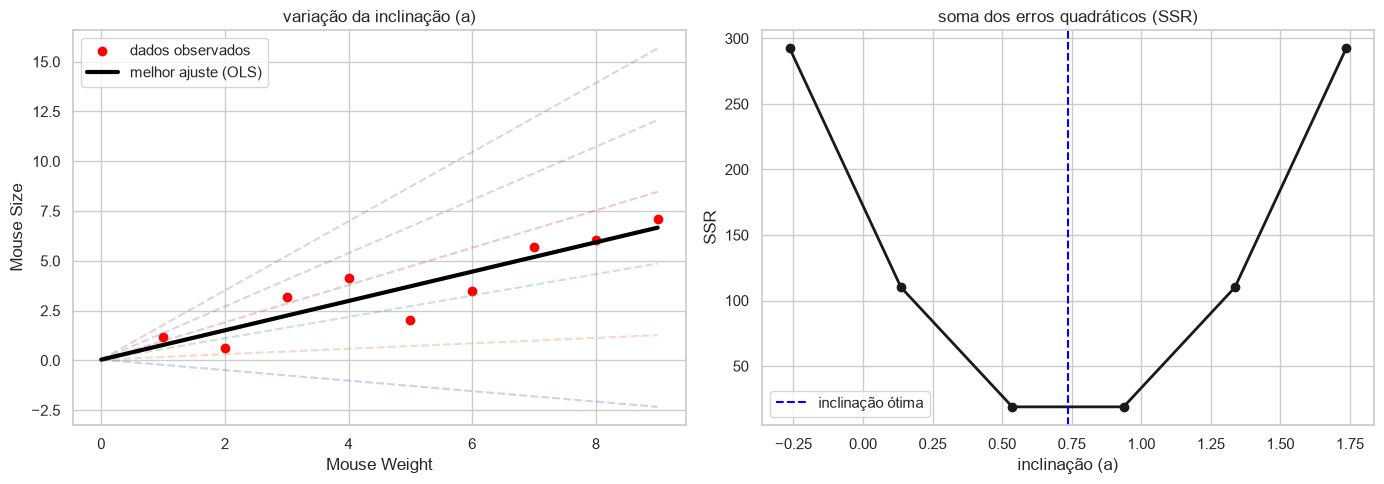

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.814
Model:                            OLS   Adj. R-squared:                  0.788
Method:                 Least Squares   F-statistic:                     30.66
Date:                Mon, 22 Jun 2026   Prob (F-statistic):           0.000871
Time:                        09:13:42   Log-Likelihood:                -11.909
No. Observations:                   9   AIC:                             27.82
Df Residuals:                       7   BIC:                             28.21
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0388      0.749      0.052      0.9

In [21]:
from sklearn.metrics import r2_score

rng = np.random.default_rng(42)
x   = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9]).reshape(-1, 1)
y   = 0.1 + 0.78 * x.flatten() + rng.normal(0, 1.0, len(x))

modelo   = LinearRegression().fit(x, y)
ideal_a  = modelo.coef_[0]
ideal_b  = modelo.intercept_

# estatísticas inferenciais via statsmodels
x_const = sm.add_constant(x)
report  = sm.OLS(y, x_const).fit()

# variação de 6 inclinações ao redor do ótimo
slopes   = np.linspace(ideal_a - 1, ideal_a + 1, 6)
ssr_list, r2_list = [], []

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.scatter(x, y, color='red', label='dados observados')
x_plot = np.linspace(0, 9, 100)
for a in slopes:
    y_calc = ideal_b + a * x_plot
    ax1.plot(x_plot, y_calc, alpha=0.3, linestyle='--')
    y_c = ideal_b + a * x.flatten()
    ssr_list.append(np.sum((y - y_c)**2))
    r2_list.append(r2_score(y, y_c))

ax1.plot(x_plot, ideal_b + ideal_a * x_plot, color='black', linewidth=3, label='melhor ajuste (OLS)')
ax1.set_title('variação da inclinação (a)')
ax1.set_xlabel('Mouse Weight'); ax1.set_ylabel('Mouse Size')
ax1.legend()

ax2.plot(slopes, ssr_list, 'o-k', linewidth=2)
ax2.axvline(ideal_a, color='blue', linestyle='--', label='inclinação ótima')
ax2.set_title('soma dos erros quadráticos (SSR)')
ax2.set_xlabel('inclinação (a)'); ax2.set_ylabel('SSR')
ax2.legend()

plt.tight_layout()
plt.show()

print(report.summary())

print("\nR² por inclinação testada:")
for a, r2 in zip(slopes, r2_list):
    print(f"  a = {a:.4f} → R² = {r2:.4f}  {'← ótimo' if abs(a - ideal_a) < 1e-6 else ''}")

### Análise e Conclusão — Questão H

A SSR forma uma parábola em torno da inclinação ótima encontrada pelo scikit-learn — qualquer desvio de $a$ aumenta o erro quadrático. O $R^2$ diminui monotonamente conforme $a$ se afasta do ótimo, confirmando que o OLS converge para o único mínimo global.

As métricas do statsmodels ($R^2$, $R^2$ ajustado, F-statistic e p-values individuais) validam a significância estatística do modelo e do coeficiente angular.

**Conclusão:** O método dos mínimos quadrados garante a inclinação de menor erro. Mesmo pequenas variações em $a$ degradam mensurável e consistentemente o ajuste, reforçando a unicidade e robustez da solução OLS.